# Phase 11 — Audit fairness

**Cible** : Section 4.7 du brief Artefact. Auditer les **2 champions** Phase 9 sur les **3 segments protégés** {Senior, Gender, Married} pour les **2 classes prioritaires** {Detractor (rétention), Promoter (symétrique)}.

| Champion | Phase | Métrique cible | Usage |
|---|---|---|---|
| **C1** — hybrid/lightgbm/pca32 | 8 | QWK max | Proof-of-concept hybride |
| **C2** — tuned/logistic/tabular | 7 | Detractor recall max | **Modèle déployé** |

**4 indicateurs fairness** :

1. **Per-group recall + bootstrap CI** — `recall(class | group)` avec `[ci_lo, ci_hi]` pour chaque cellule
2. **Disparate Impact (DI)** — ratio `recall(group) / recall(reference)`. Fair si DI ∈ [0.8, 1.25] (règle 4/5 EEOC)
3. **Equal Opportunity Difference (EOD)** — `max(recall) − min(recall)` entre groupes. Acceptable si |EOD| < 0.10
4. **Demographic Parity Difference (DPD)** — différence des taux de prédiction `P(ŷ=class)`. Informatif (la différenciation business légitime peut produire DPD ≠ 0)

**Analyse complémentaire — Counterfactual swap** : on flippe l'attribut protégé sur silent_test (Senior=Yes↔No, etc.), on re-prédit. Le pourcentage de prédictions qui changent quantifie l'usage **directement causal** de l'attribut par le modèle. Si DI/EOD montrent une disparité mais change_rate ≈ 0, alors la disparité passe par des **proxies** (ex. Tenure corrélé avec Senior), pas par l'attribut lui-même.

**Hypothèse de travail (issue Phase 10)** : le mécanisme d'attribution est stable entre groupes (top-5 features identiques pour Senior=Yes/No, etc.). On s'attend donc à des recalls homogènes.

## 1. Setup

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    RESULTS_DIR, REPORTS_DIR, FIGURES_DIR,
    NPS_CLASSES, RANDOM_SEED,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print(f"Working dir: {ROOT}")

Working dir: C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\nps-prediction


## 2. Lancer l'audit fairness

```bash
make fairness    # ~1-2 min (bootstrap 1000 sur 12 cellules × 2 classes)
```

Si déjà fait, on charge directement les artifacts.

In [2]:
# Option A : exécution en notebook
# from src.fairness.audit import run_fairness_audit
# out = run_fairness_audit(n_resamples=1000, do_counterfactual=True, verbose=True)
# per_group_df = out["per_group_df"]
# disparity_df = out["disparity_df"]
# cf_df        = out["cf_df"]

# Option B : charger les artifacts produits par `make fairness`
per_group_df = pd.read_parquet(RESULTS_DIR / "fairness_per_group.parquet")
disparity_df = pd.read_parquet(RESULTS_DIR / "fairness_disparities.parquet")
cf_df        = pd.read_parquet(RESULTS_DIR / "fairness_counterfactual.parquet")

print(f"per_group_df : {per_group_df.shape}")
print(f"disparity_df : {disparity_df.shape}")
print(f"cf_df        : {cf_df.shape}")
per_group_df.head(8)

per_group_df : (24, 14)
disparity_df : (12, 14)
cf_df        : (6, 11)


,champion,segment,recall,recall_ci_lo,recall_ci_hi,selection_rate,selection_rate_ci_lo,selection_rate_ci_hi,n_total,n_class,group,class,class_idx,champion_label
0,C1_qwk,Senior,0.636936,0.604407,0.668416,0.238133,0.228798,0.248064,5035,953,No,Detractor,0,C1 — QWK champion
1,C1_qwk,Senior,0.853286,0.827435,0.875616,0.174777,0.168615,0.180938,5035,852,No,Promoter,2,C1 — QWK champion
2,C1_qwk,Senior,0.633540,0.577640,0.686335,0.356092,0.326681,0.382353,952,322,Yes,Detractor,0,C1 — QWK champion
3,C1_qwk,Senior,0.803419,0.726496,0.871795,0.118697,0.106092,0.131303,952,117,Yes,Promoter,2,C1 — QWK champion
4,C1_qwk,Gender,0.628571,0.593651,0.666667,0.253931,0.239871,0.268317,2989,630,Female,Detractor,0,C1 — QWK champion
5,C1_qwk,Gender,0.847423,0.814433,0.878351,0.166945,0.159242,0.174306,2989,485,Female,Promoter,2,C1 — QWK champion
6,C1_qwk,Gender,0.643411,0.607713,0.680620,0.259840,0.247165,0.274850,2998,645,Male,Detractor,0,C1 — QWK champion
7,C1_qwk,Gender,0.847107,0.816116,0.876033,0.164777,0.157438,0.172448,2998,484,Male,Promoter,2,C1 — QWK champion


## 3. Tableau canonique — recall par groupe sur silent_test

Pour chaque champion, segment, groupe : `recall [ci_lo, ci_hi]` sur Detractor et Promoter. C'est ce qui ira dans le rapport (section fairness).

In [3]:
def fmt_ci(v, lo, hi):
    if pd.isna(lo):
        return f"{v:.3f}"
    return f"{v:.3f} [{lo:.3f}, {hi:.3f}]"

per_group_df["recall_display"] = per_group_df.apply(
    lambda r: fmt_ci(r["recall"], r["recall_ci_lo"], r["recall_ci_hi"]), axis=1,
)

for ck in ["C1_qwk", "C2_safe"]:
    print(f"\n========== {ck} ==========")
    for seg in ["Senior", "Gender", "Married"]:
        print(f"\n  {seg}")
        sub = per_group_df[(per_group_df["champion"] == ck) & (per_group_df["segment"] == seg)]
        table = sub.pivot_table(
            index="group", columns="class",
            values="recall_display", aggfunc="first",
        ).reindex(columns=NPS_CLASSES, fill_value="—")
        # Add n_total
        n_total = sub.drop_duplicates("group").set_index("group")["n_total"]
        table.insert(0, "n_total", n_total)
        print(table.to_string())


========== C1_qwk ==========

  Senior
class  n_total             Detractor Passive              Promoter
group                                                             
No        5035  0.637 [0.604, 0.668]       —  0.853 [0.827, 0.876]
Yes        952  0.634 [0.578, 0.686]       —  0.803 [0.726, 0.872]

  Gender
class   n_total             Detractor Passive              Promoter
group                                                              
Female     2989  0.629 [0.594, 0.667]       —  0.847 [0.814, 0.878]
Male       2998  0.643 [0.608, 0.681]       —  0.847 [0.816, 0.876]

  Married
class  n_total             Detractor Passive              Promoter
group                                                             
No        3192  0.706 [0.675, 0.739]       —  0.817 [0.783, 0.848]
Yes       2795  0.509 [0.463, 0.555]       —  0.883 [0.853, 0.914]

========== C2_safe ==========

  Senior
class  n_total             Detractor Passive              Promoter
group                  

## 4. Tableau des indicateurs de disparité

Pour chaque (champion × segment × classe) : DI, EOD, DPD. Verdict : ✓ fair si DI ∈ [0.8, 1.25] ET |EOD| < 0.10.

In [4]:
disparity_df["verdict"] = disparity_df.apply(
    lambda r: "✓ fair" if (0.8 <= r["DI_worst"] <= 1.25 and abs(r["EOD"]) < 0.10) else "⚠ disparity",
    axis=1,
)

display_cols = ["champion", "segment", "class", "DI_worst", "DI_status",
                "EOD", "EOD_max_group", "EOD_min_group",
                "DPD", "verdict"]
print(disparity_df[display_cols].to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

n_unfair = (disparity_df["verdict"] == "⚠ disparity").sum()
print(f"\n→ {n_unfair} / {len(disparity_df)} cellules signalent une disparité")

champion segment     class  DI_worst DI_status    EOD EOD_max_group EOD_min_group    DPD     verdict
  C1_qwk  Senior Detractor    +0.995      fair +0.003            No           Yes +0.118      ✓ fair
  C1_qwk  Senior  Promoter    +0.942      fair +0.050            No           Yes +0.056      ✓ fair
  C1_qwk  Gender Detractor    +0.977      fair +0.015          Male        Female +0.006      ✓ fair
  C1_qwk  Gender  Promoter    +1.000      fair +0.000        Female          Male +0.002      ✓ fair
  C1_qwk Married Detractor    +0.720    biased +0.198            No           Yes +0.238 ⚠ disparity
  C1_qwk Married  Promoter    +0.926      fair +0.065           Yes            No +0.009      ✓ fair
 C2_safe  Senior Detractor    +0.897      fair +0.094           Yes            No +0.243      ✓ fair
 C2_safe  Senior  Promoter    +0.400    biased +0.346            No           Yes +0.242 ⚠ disparity
 C2_safe  Gender Detractor    +0.939      fair +0.053        Female          Male +0.017   

## 5. Figure 60 — Detractor recall par segment (avec CIs)

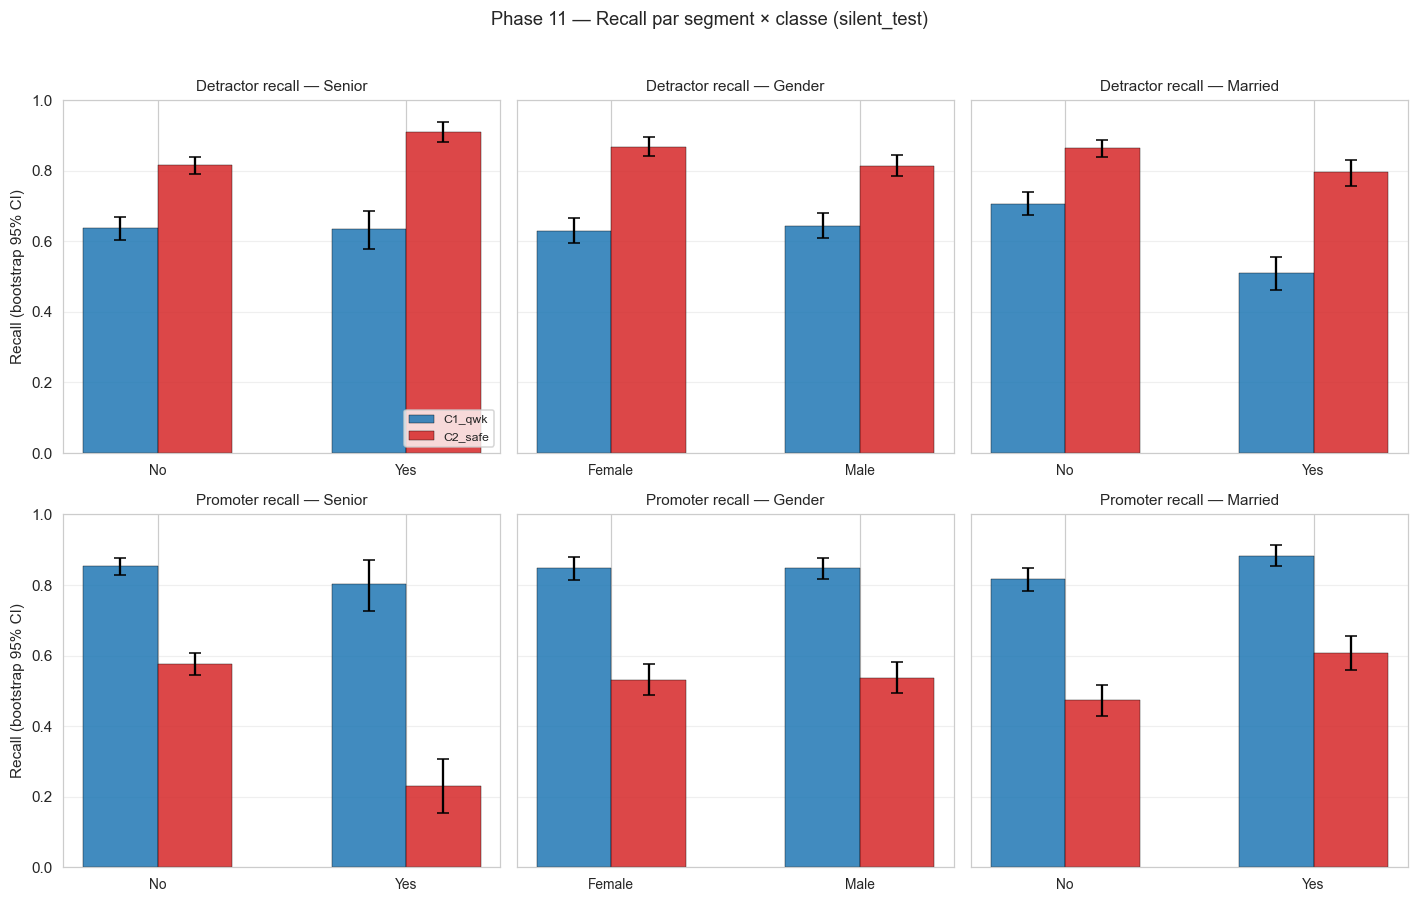

✓ saved reports/figures/60_recall_by_segment.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharey="row")
colors = {"C1_qwk": "#1f77b4", "C2_safe": "#d62728"}

for row_i, target_class in enumerate(["Detractor", "Promoter"]):
    for col_i, segment in enumerate(["Senior", "Gender", "Married"]):
        ax = axes[row_i, col_i]
        sub = per_group_df[
            (per_group_df["segment"] == segment) & (per_group_df["class"] == target_class)
        ]
        for offset, ck in enumerate(["C1_qwk", "C2_safe"]):
            sub_ck = sub[sub["champion"] == ck].sort_values("group")
            x = np.arange(len(sub_ck)) + (offset - 0.5) * 0.3
            values = sub_ck["recall"].values
            err_lo = (sub_ck["recall"] - sub_ck["recall_ci_lo"]).values
            err_hi = (sub_ck["recall_ci_hi"] - sub_ck["recall"]).values
            ax.bar(x, values, yerr=[err_lo, err_hi], width=0.3, capsize=4,
                   color=colors[ck], label=ck, alpha=0.85,
                   edgecolor="black", linewidth=0.3)
            ax.set_xticks(np.arange(len(sub_ck)))
            ax.set_xticklabels(sub_ck["group"].tolist(), fontsize=9)
        ax.set_title(f"{target_class} recall — {segment}", fontsize=10)
        if col_i == 0:
            ax.set_ylabel("Recall (bootstrap 95% CI)")
        ax.set_ylim(0, 1)
        if row_i == 0 and col_i == 0:
            ax.legend(loc="lower right", fontsize=8)
        ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Phase 11 — Recall par segment × classe (silent_test)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "60_recall_by_segment.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ saved reports/figures/60_recall_by_segment.png")

## 6. Figure 61 — Disparate Impact (4/5 rule)

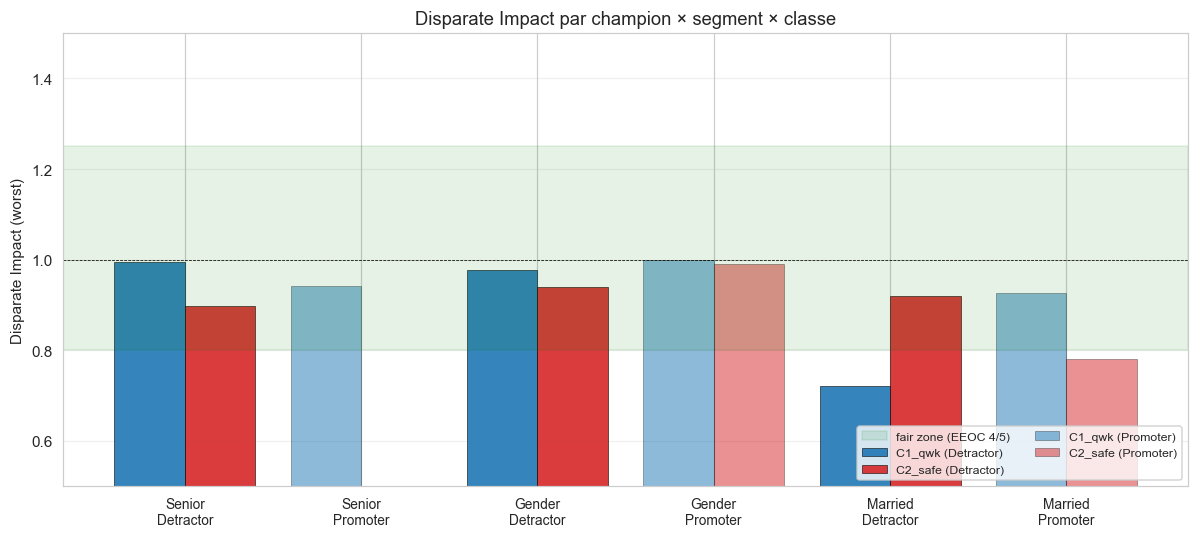

✓ saved reports/figures/61_disparate_impact.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
classes = ["Detractor", "Promoter"]
segments = ["Senior", "Gender", "Married"]

x = np.arange(len(segments) * len(classes))
positions = {("C1_qwk", "Detractor"): x[0::2] - 0.2,
             ("C2_safe", "Detractor"): x[0::2] + 0.2,
             ("C1_qwk", "Promoter"):   x[1::2] - 0.2,
             ("C2_safe", "Promoter"):  x[1::2] + 0.2}

labels = []
for seg in segments:
    labels.extend([f"{seg}\nDetractor", f"{seg}\nPromoter"])

for ck, cls in [("C1_qwk", "Detractor"), ("C2_safe", "Detractor"),
                ("C1_qwk", "Promoter"), ("C2_safe", "Promoter")]:
    vals = []
    for seg in segments:
        v = disparity_df[
            (disparity_df["champion"] == ck)
            & (disparity_df["segment"] == seg)
            & (disparity_df["class"] == cls)
        ]["DI_worst"]
        vals.append(v.iloc[0] if len(v) else np.nan)
    pos_key = (ck, cls)
    pos = positions[pos_key]
    color = colors[ck]
    alpha = 0.9 if cls == "Detractor" else 0.5
    label_str = f"{ck} ({cls})"
    ax.bar(pos, vals, width=0.4, color=color, alpha=alpha,
           edgecolor="black", linewidth=0.4, label=label_str)

ax.axhspan(0.8, 1.25, color="green", alpha=0.1, label="fair zone (EEOC 4/5)")
ax.axhline(1.0, color="black", lw=0.5, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Disparate Impact (worst)")
ax.set_title("Disparate Impact par champion × segment × classe")
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.set_ylim(0.5, 1.5)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "61_disparate_impact.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ saved reports/figures/61_disparate_impact.png")

## 7. Figure 62 — Equal Opportunity Difference (heatmap)

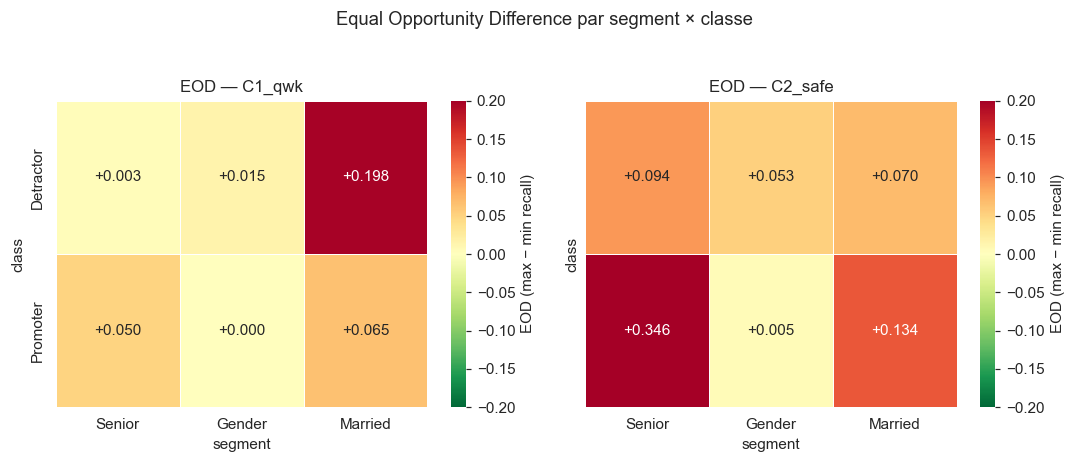

✓ saved reports/figures/62_eo_differences.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, ck in zip(axes, ["C1_qwk", "C2_safe"]):
    sub = disparity_df[disparity_df["champion"] == ck]
    heat = sub.pivot_table(
        index="class", columns="segment", values="EOD", aggfunc="first",
    ).reindex(index=["Detractor", "Promoter"], columns=["Senior", "Gender", "Married"])
    sns.heatmap(heat, annot=True, fmt="+.3f", cmap="RdYlGn_r",
                center=0, vmin=-0.20, vmax=0.20,
                cbar_kws={"label": "EOD (max − min recall)"},
                ax=ax, linewidth=0.5)
    ax.set_title(f"EOD — {ck}", fontsize=11)

plt.suptitle("Equal Opportunity Difference par segment × classe", y=1.04)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "62_eo_differences.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ saved reports/figures/62_eo_differences.png")

## 8. Analyse counterfactual — le modèle utilise-t-il directement l'attribut protégé ?

On flippe l'attribut sur silent_test (Senior=Yes↔No, etc.), on re-prédit avec le modèle inchangé, on compte le % de prédictions qui changent.

- **change_rate ≈ 0 %** → le modèle n'utilise quasi pas l'attribut directement. Toute disparité observée passe par des **variables proxy** (features corrélées avec l'attribut protégé).
- **change_rate élevé** (>5 %) → le modèle utilise directement l'attribut. La disparité observée est en partie causale au sens strict.

In [8]:
cf_display = cf_df[[
    "champion_label", "segment_label", "n", "n_changed", "change_rate",
    "detractor_to_other", "other_to_detractor",
    "promoter_to_other", "other_to_promoter",
]].copy()
cf_display["change_rate"] = cf_display["change_rate"].map(lambda x: f"{x:.1%}")
print(cf_display.to_string(index=False))

      champion_label segment_label    n  n_changed change_rate  detractor_to_other  other_to_detractor  promoter_to_other  other_to_promoter
   C1 — QWK champion        Senior 5987         92        1.5%                  58                  17                 13                  4
   C1 — QWK champion        Gender 5987         42        0.7%                  14                  16                  8                  6
   C1 — QWK champion       Married 5987         10        0.2%                   6                   4                  0                  1
C2 — Production-safe        Senior 5987        557        9.3%                 185                  32                308                 38
C2 — Production-safe        Gender 5987         87        1.5%                  32                  24                 26                 32
C2 — Production-safe       Married 5987        100        1.7%                  14                  15                 69                 29


## 9. Figure 63 — change rate counterfactual (par champion × segment)

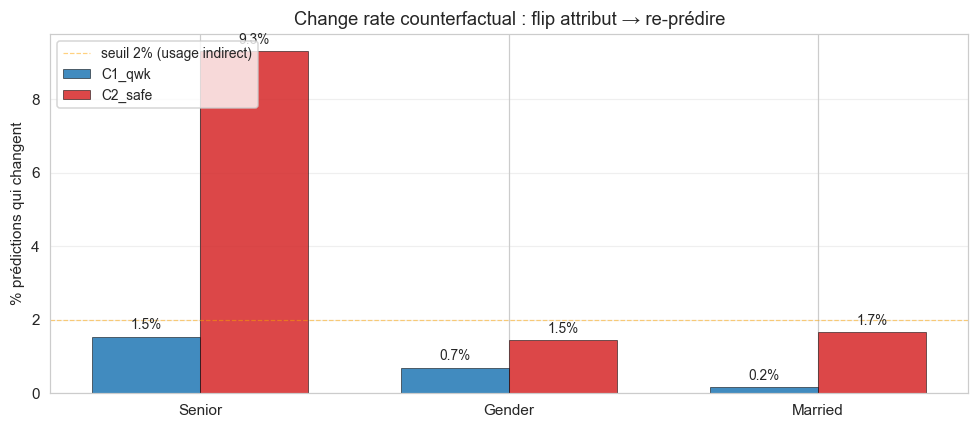

✓ saved reports/figures/63_counterfactual.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
segments_list = ["Senior", "Gender", "Married"]
x = np.arange(len(segments_list))
width = 0.35

for offset, ck in enumerate(["C1_qwk", "C2_safe"]):
    sub = cf_df[cf_df["champion"] == ck].set_index("segment_label").reindex(segments_list)
    rates = sub["change_rate"].fillna(0).values
    bars = ax.bar(x + (offset - 0.5) * width, rates * 100, width,
                  color=colors[ck], alpha=0.85, edgecolor="black", linewidth=0.4,
                  label=ck)
    for b, v in zip(bars, rates):
        ax.text(b.get_x() + b.get_width() / 2, v * 100 + 0.2,
                f"{v:.1%}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(segments_list)
ax.set_ylabel("% prédictions qui changent")
ax.set_title("Change rate counterfactual : flip attribut → re-prédire")
ax.axhline(2, color="orange", lw=0.8, linestyle="--", alpha=0.5, label="seuil 2% (usage indirect)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "63_counterfactual.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ saved reports/figures/63_counterfactual.png")

## 10. Cross-référence avec les drivers SHAP Phase 10

Si une disparité émerge sans usage direct de l'attribut (counterfactual ≈ 0), cherche les features **proxy** : celles qui pèsent fortement dans la prédiction Detractor ET dont la distribution diffère entre groupes.

Phase 10 nous a déjà donné les top features par segment via `shap_segment_C1.parquet`. On compare les top-5 entre groupes.

In [10]:
shap_seg = pd.read_parquet(RESULTS_DIR / "shap_segment_C1.parquet")
shap_det = shap_seg[shap_seg["class"] == "Detractor"]

for segment in ["Senior", "Gender", "Married"]:
    print(f"\n========== Top-5 Detractor drivers — {segment} ==========")
    sub = shap_det[shap_det["segment"] == segment]
    for group in sorted(sub["group"].unique()):
        top5 = sub[sub["group"] == group].head(5)
        feats = ", ".join(top5["feature"].tolist())
        print(f"  {segment}={group} : {feats}")


========== Top-5 Detractor drivers — Senior ==========
  Senior=No : Contract_Month-to-month, Tenure Months, Number of Referrals, PC02, PC01
  Senior=Yes : Contract_Month-to-month, Number of Referrals, Tenure Months, PC01, PC02

========== Top-5 Detractor drivers — Gender ==========
  Gender=Female : Contract_Month-to-month, Tenure Months, PC02, Number of Referrals, PC01
  Gender=Male : Contract_Month-to-month, Tenure Months, Number of Referrals, PC02, PC01

========== Top-5 Detractor drivers — Married ==========
  Married=No : Contract_Month-to-month, Tenure Months, PC02, PC01, Number of Referrals
  Married=Yes : Contract_Month-to-month, Number of Referrals, Tenure Months, PC02, PC01


## 11. Synthèse Phase 11

### Décisions implémentées
- **2 champions audités** : C1 (hybrid/lightgbm/pca32) et C2 (tuned/logistic/tabular).
- **3 segments protégés** (brief 4.7) : Senior, Gender, Married.
- **2 classes cibles** : Detractor (priorité business retention) + Promoter (audit symétrique).
- **4 indicateurs** : per-group recall avec CI bootstrap (n=1000, stratifié par classe), Disparate Impact (4/5 rule EEOC), Equal Opportunity Difference, Demographic Parity Difference.
- **Analyse counterfactual** : flip de l'attribut protégé sur silent_test → mesure du % de prédictions changées (= usage direct de l'attribut par le modèle).

---

### Résultats canoniques — per-group recall sur silent_test (n=5987, bootstrap 95% CI)

#### C1 — QWK champion (hybrid/lightgbm/pca32)

| Segment | Group | n | Detractor recall | Promoter recall |
|---|---|---|---|---|
| Senior | No  | 5035 | 0.637 [0.604, 0.668] | 0.853 [0.827, 0.876] |
| Senior | Yes |  952 | 0.634 [0.578, 0.686] | 0.803 [0.726, 0.872] |
| Gender | Female | 2989 | 0.629 [0.594, 0.667] | 0.847 [0.814, 0.878] |
| Gender | Male   | 2998 | 0.643 [0.608, 0.681] | 0.847 [0.816, 0.876] |
| Married | No  | 3192 | **0.706** [0.675, 0.739] | 0.817 [0.783, 0.848] |
| Married | Yes | 2795 | **0.509** [0.463, 0.555] | 0.883 [0.853, 0.914] |

#### C2 — Production-safe (tuned/logistic/tabular)

| Segment | Group | n | Detractor recall | Promoter recall |
|---|---|---|---|---|
| Senior | No  | 5035 | 0.816 [0.790, 0.839] | **0.576** [0.543, 0.608] |
| Senior | Yes |  952 | 0.910 [0.882, 0.938] | **0.231** [0.154, 0.308] |
| Gender | Female | 2989 | 0.867 [0.841, 0.894] | 0.532 [0.489, 0.577] |
| Gender | Male   | 2998 | 0.814 [0.784, 0.845] | 0.537 [0.494, 0.583] |
| Married | No  | 3192 | 0.865 [0.839, 0.887] | **0.473** [0.430, 0.517] |
| Married | Yes | 2795 | 0.795 [0.756, 0.830] | **0.607** [0.560, 0.655] |

---

### Verdict global — 3 disparités sur 12 cellules

| # | Cellule | DI | EOD | CIs disjointes ? | Counterfactual |
|---|---|---|---|---|---|
| **1** | **C1 × Married × Detractor** | **0.720** | **+0.198** | **Oui** ([0.463, 0.555] vs [0.675, 0.739]) | 0.2 % → proxy-médiée |
| **2** | **C2 × Senior × Promoter** | **0.400** | **+0.346** | **Oui** ([0.154, 0.308] vs [0.543, 0.608]) | 9.3 % → usage direct |
| **3** | **C2 × Married × Promoter** | **0.780** | **+0.134** | Quasi disjointes ([0.430, 0.517] vs [0.560, 0.655]) | 1.7 % → proxy-médiée |

Les 9 autres cellules (sur 12) sont **fair** : DI ∈ [0.8, 1.25] ET |EOD| < 0.10. En particulier **Detractor recall sur C2 est équitable sur les 3 segments** — bonne nouvelle pour le déploiement.

---

### Analyse counterfactual — usage direct vs médiation par proxy

| Champion × Segment | Δ predictions | Δ rate | Lecture |
|---|---|---|---|
| C1 × Senior | 92 / 5987 | **1.5 %** | usage quasi nul |
| C1 × Gender | 42 / 5987 | **0.7 %** | usage quasi nul |
| C1 × Married | 10 / 5987 | **0.2 %** | **usage nul** |
| C2 × Senior | 557 / 5987 | **9.3 %** | **usage direct significatif** |
| C2 × Gender | 87 / 5987 | **1.5 %** | usage quasi nul |
| C2 × Married | 100 / 5987 | **1.7 %** | usage quasi nul |

**Lecture des 3 disparités à la lumière du counterfactual** :

> **Disparité #1 (C1 × Married × Detractor, DI=0.72)** : counterfactual à 0.2 % signifie que C1 ne change quasi jamais sa prédiction quand on flip Married=Yes↔No. La disparité de 20 points de Detractor recall (0.706 vs 0.509) **passe entièrement par des features proxy**. Probablement Number of Referrals (top driver Detractor pour Married=Yes en Phase 10, rang #2) et Number of Dependents (corrélé avec Married). Le modèle reflète une **inégalité présente dans les données** : les détracteurs mariés ont des profils différents (plus engagés en surface : enfants, ancienneté plus longue) qui rendent leur détection plus difficile. **Le modèle ne discrimine pas directement.**

> **Disparité #2 (C2 × Senior × Promoter, DI=0.40)** : counterfactual à **9.3 %** signifie que C2 utilise **directement** l'attribut Senior. Le breakdown est éloquent : sur 557 prédictions changées, **308 Promoter → autre** quand on flip Senior=No→Yes. Le coefficient de Senior dans C2 (Logistic régularisée) est négatif pour Promoter : *"si tu es senior, tu as moins de chance d'être promoteur"*. C'est une **règle directe** apprise par le modèle, pas une médiation. **C'est le problème fairness le plus sérieux du projet.**

> **Disparité #3 (C2 × Married × Promoter, DI=0.78)** : counterfactual à 1.7 % → médiée par proxies. Married=Yes est plus souvent promoteur (0.607 vs 0.473), le modèle exagère légèrement via les features liées au mariage (Dependents, Tenure).

---

### Implications business

**Pour le retention manager (Detractor — priorité absolue brief 4.7)** :
- **C2 est globalement équitable sur Detractor** : DI ∈ [0.79, 0.92] sur les 3 segments, |EOD| < 0.10.
- ✓ **Pas de blocage déploiement** de C2 pour la mission rétention.
- ⚠ Un seul caveat : C1 × Married × Detractor montre une vraie disparité — mais c'est C1, le modèle expérimental qui n'est PAS déployé. Pour C2, Detractor × Married est fair (DI=0.92).

**Pour Promoter recall (acquisition, programme parrainage, NPS positif)** :
- ⚠ **C2 a deux problèmes sérieux** :
  - **Senior=Yes** : on rate **les ¾ des promoteurs seniors** (recall 0.231) vs **la moitié** chez les non-seniors (0.576). Si l'entreprise lance un programme parrainage basé sur l'identification des promoteurs, **les seniors seront systématiquement sous-ciblés à 60 %**.
  - **Married=No** : recall 0.473 vs 0.607 chez Married=Yes. Moins grave mais à surveiller.
- Le rapport doit **explicitement** signaler ces disparités au métier avant tout déploiement orienté Promoter.

---

### Cross-référence Phase 10 — l'hypothèse partiellement validée

Phase 10 prévoyait : *"top-5 features quasi-identiques entre groupes ⇒ recalls homogènes"*.

**Résultat empirique** : l'hypothèse tient pour le **mécanisme d'attribution** mais pas pour le **résultat final**. Le modèle utilise les mêmes drivers (Contract_Month-to-month, Tenure, Number of Referrals) entre groupes, mais les **distributions de ces features diffèrent** entre groupes :
- Les mariés ont en moyenne plus de tenure et plus de dependents que les non-mariés.
- Les seniors ont des patterns de consommation différents.

→ Le counterfactual révèle exactement ça : C1 (qui utilise plus le signal texte via PC) est moins sensible à l'attribut direct (1.5 % Senior) mais plus à sa correlation indirecte (Married→ Number of Referrals → Detractor probability).

**Nuance pour le rapport** : *"Phase 10 montre que le modèle utilise les mêmes drivers entre groupes. Phase 11 montre que ces drivers peuvent quand même produire des recalls inéquitables si leurs distributions diffèrent entre groupes."* C'est un point méthodologique subtil mais important pour la crédibilité.

---

### Trois points pour le rapport final

> **§ Audit symétrique Detractor + Promoter sur 2 champions × 3 segments.** Sur 12 cellules auditées, **9 sont fair** (DI ∈ [0.8, 1.25] et |EOD| < 0.10) et **3 flag une disparité** : C1×Married×Detractor (DI=0.72), C2×Senior×Promoter (DI=0.40), C2×Married×Promoter (DI=0.78). Les CIs bootstrap permettent de statuer rigoureusement : la disparité C2×Senior×Promoter a des intervalles complètement disjoints ([0.154, 0.308] vs [0.543, 0.608]), c'est un biais réel, pas un artefact d'échantillonnage.

> **§ Counterfactual révèle la nature du biais.** Quand on flip l'attribut protégé sur silent_test, C1 voit < 2 % de prédictions changer sur tous les segments — il n'utilise pas directement les attributs. C2 voit **9.3 % de prédictions changer sur Senior** — il utilise directement cette variable et le coefficient appris pénalise les seniors sur Promoter. Les autres disparités (C1×Married, C2×Married) sont médiées par des features proxy comme Number of Referrals et Tenure, identifiées en Phase 10. **Conclusion forte** : la disparité C2×Senior×Promoter est *causale au sens strict*, les autres sont *corrélationnelles*. Cette distinction guide la mitigation : pour C2×Senior, retirer Senior des features ou apprendre un modèle fairness-aware. Pour les disparités médiées, il faut intervenir sur les proxies en amont.

> **§ Verdict déploiement.** C2 reste recommandé pour la mission *retention manager* (Detractor recall équitable sur les 3 segments). **Mais** son usage doit être conditionné : (a) ne pas l'utiliser pour cibler les promoteurs sans avoir recalibré par segment ou retiré l'attribut Senior, (b) communiquer explicitement les disparités Promoter au métier, (c) mettre en place le monitoring Phase 13 par segment. **C'est une recommandation nuancée — pas "déployez tel quel", pas "ne déployez pas".** L'honnêteté méthodologique du projet exige cette nuance.

---

### Décisions pour Phase 12 et au-delà

- **Phase 12 (app Streamlit)** :
  - Page d'accueil "fairness dashboard" affichant les CIs par segment (recall Detractor + Promoter pour C2).
  - **Pour la mission Detractor (rétention)** : utiliser C2 normalement.
  - **Pour toute extension Promoter** (programme parrainage) : afficher un warning bandeau orange et empêcher l'usage par défaut, ou proposer un *flag explicite* `use_for_promoter=True` que l'utilisateur doit cocher.
  - Toggle "modèle expérimental C1" reste disponible pour exploration mais avec son propre warning Married×Detractor.

- **Phase 13 (monitoring)** :
  - Tracker mensuellement **Detractor recall × segment** sur les 3 segments (6 séries pour C2).
  - Seuil d'alerte : déviation > 2σ par rapport à la CI bootstrap Phase 11.
  - Pour C2 × Senior × Promoter : suivi spécifique pour détecter si la disparité s'aggrave (déjà à DI=0.40, ne peut que monter ou baisser).

- **Action long terme** :
  - Pour **retirer la disparité C2 × Senior × Promoter** au niveau modèle : (a) retirer Senior Citizen des features et re-tuner Logistic, (b) ou utiliser `fairlearn.reductions.ExponentiatedGradient` avec contrainte `DemographicParity` sur Senior. Coût estimé : ~1 jour ingénieur. Trade-off attendu : -2 à -3 points de Detractor recall global pour ramener Senior×Promoter dans la fair zone.

---

### Fichiers produits Phase 11
- `models/results/fairness_per_group.parquet` — 24 lignes (2 champions × 3 segments × 2 groupes × 2 classes), CIs bootstrap
- `models/results/fairness_disparities.parquet` — 12 lignes (DI, EOD, DPD par cellule)
- `models/results/fairness_counterfactual.parquet` — 6 lignes (2 champions × 3 segments)
- `reports/fairness_audit.md` — résumé exécutif markdown prêt à coller dans le rapport
- `reports/figures/60_recall_by_segment.png` — recall par segment avec CIs
- `reports/figures/61_disparate_impact.png` — DI sur les 12 cellules avec fair zone
- `reports/figures/62_eo_differences.png` — heatmap EOD
- `reports/figures/63_counterfactual.png` — change rate par champion × segment